Question 4.1

In [14]:
x = [1,2,3,10]
y = [10, 20, 30, 40]

z = [x + y for x, y in zip(x,y)]
print(list(z))

def xplusy (x,y):
    return x+y
z1 = map(xplusy, x, y)
print(list(z1))

[11, 22, 33, 50]
[11, 22, 33, 50]


Q 4.3

In [37]:
import numpy as np
rps = input("Enter rock, paper or scissors using R, P or S: ")  #Human can choose rock, paper or scissors


RPS = np.array([ 'R', 'P' , 'S'])                               #computer randomly picks rock paper or scissor
indx = np.random.randint(0, len(RPS), 1)
print("Computer's choise: ", RPS[indx])

if RPS[indx] == 'P' and rps == 'P':                            #all the ways the computer can win, the human can win or that they can draw
    print("draw")

elif RPS[indx] == 'R' and rps == 'R':
    print("draw")

elif RPS[indx] == 'S' and rps == 'S':
    print("draw")

elif RPS[indx] == 'P' and rps == 'S':
    print("human wins")

elif RPS[indx] == 'S' and rps == 'P':
    print("computer wins")

elif RPS[indx] == 'R' and rps == 'P':
    print("Human wins")

elif RPS[indx] == 'P' and rps == 'R':
    print("Computer wins")

elif RPS[indx] == 'R' and rps == 'P':
    print("Human wins")

else:
    print("Computer wins")

Enter rock, paper or scissors using R, P or S:  P


Computer's choise:  ['P']
draw


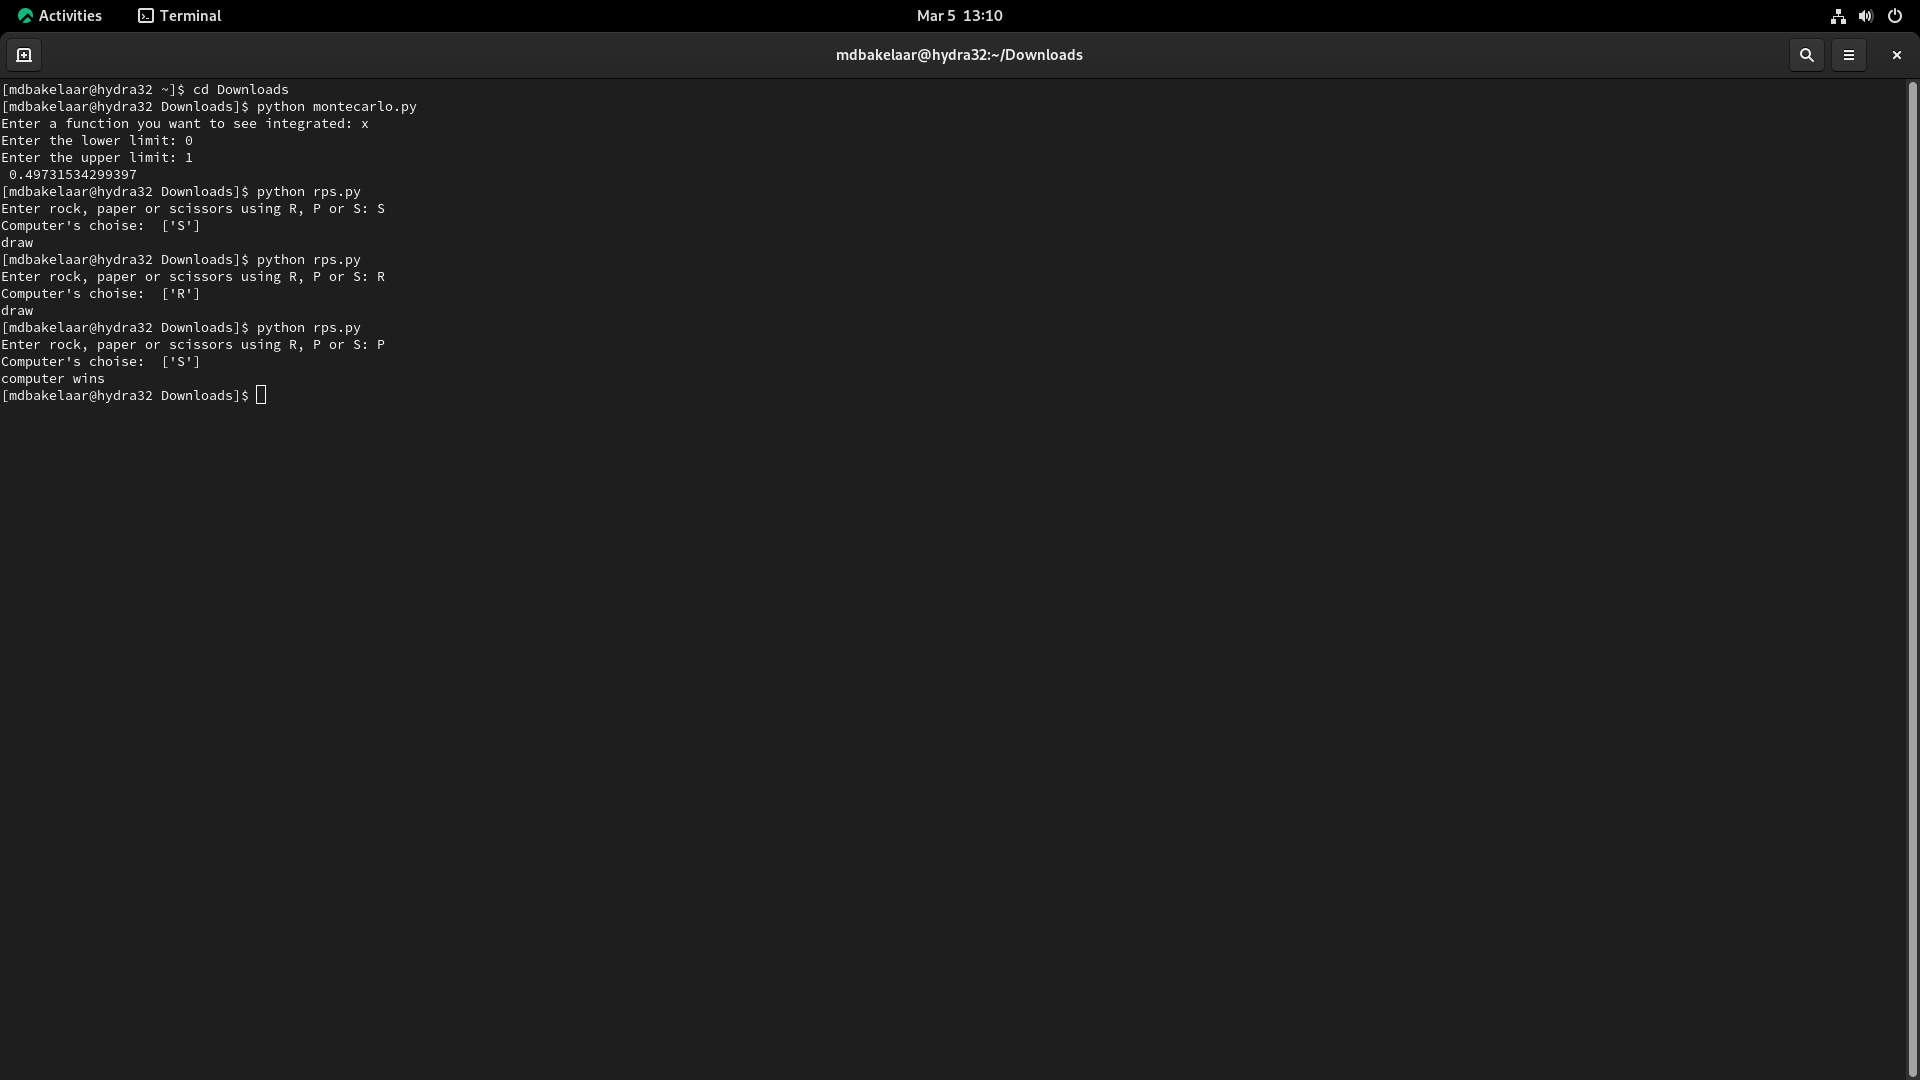

Q 4.4

Subset of random lengths: [185.56103386 165.14998042 170.11911839 201.91498991 188.14527451
 186.73133123 190.57720052 193.02878036 186.58399266 193.07454985]


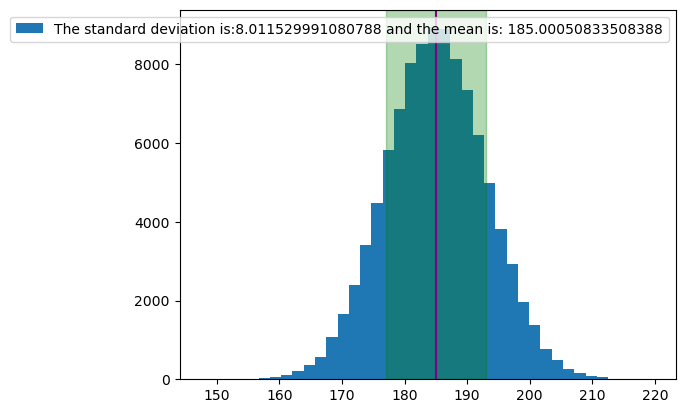

The mean is: 185.00050833508388
The standard deviation is: 8.011529991080788


Enter a height you want to know the probability of there being some higher than:  185


Probability to find a length of 185 cm or smaller in our sample is: 50.00 %
The probability to find a length of 185 cm and a standard deviation around it is: 68.34 %


In [5]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import norm

lengths = np.random.normal(185, 8, 100000)
print("Subset of random lengths:", lengths[:10])

stdev = np.std(lengths)
maen = np.mean(lengths)

plt.hist(lengths, bins=40, label=f"The standard deviation is:{stdev} and the mean is: {maen}")
plt.legend()
plt.axvline(maen, color='purple')
plt.axvspan(maen - stdev , maen + stdev, color='green', alpha=0.3)
plt.show()

print(f"The mean is: {maen}")
print(f"The standard deviation is: {stdev}")

h = input("Enter a height you want to know the probability of there being some higher than: ")
cdf = norm.cdf(int(h), scale=8, loc=185 )
P = 1 - cdf
P *= 100 # to percentage
D = 100 - P
print(f"Probability to find a length of {h} cm or smaller in our sample is: {D:.2f} %")

less = norm.cdf(maen - stdev, scale=8, loc=185)
more = norm.cdf(maen + stdev, scale=8, loc=185)
perc = (more - less)*100
print(f"The probability to find a length of {h} cm and a standard deviation around it is: {perc:.2f} %")

Question 4.6

In [37]:
import numpy as np
from math import *

fx = input("Enter a function you want to see integrated: ")      #Input a function, upper and lower bound
a = float(input("Enter the lower limit: "))
b = float(input("Enter the upper limit: "))


x = np.random.uniform(a, b, 10000)          #make a list with the upper and lower bound and the amount of numbers inbetween


def montecarlo(fx, a, b):                           #make a function to calculate
    montecarlo = ((b-a)/len(x))*np.sum(eval(fx))
    return(montecarlo)

print(f" {montecarlo(fx, a, b)}")

Enter a function you want to see integrated:  x
Enter the lower limit:  0
Enter the upper limit:  1


 0.49902557847370194


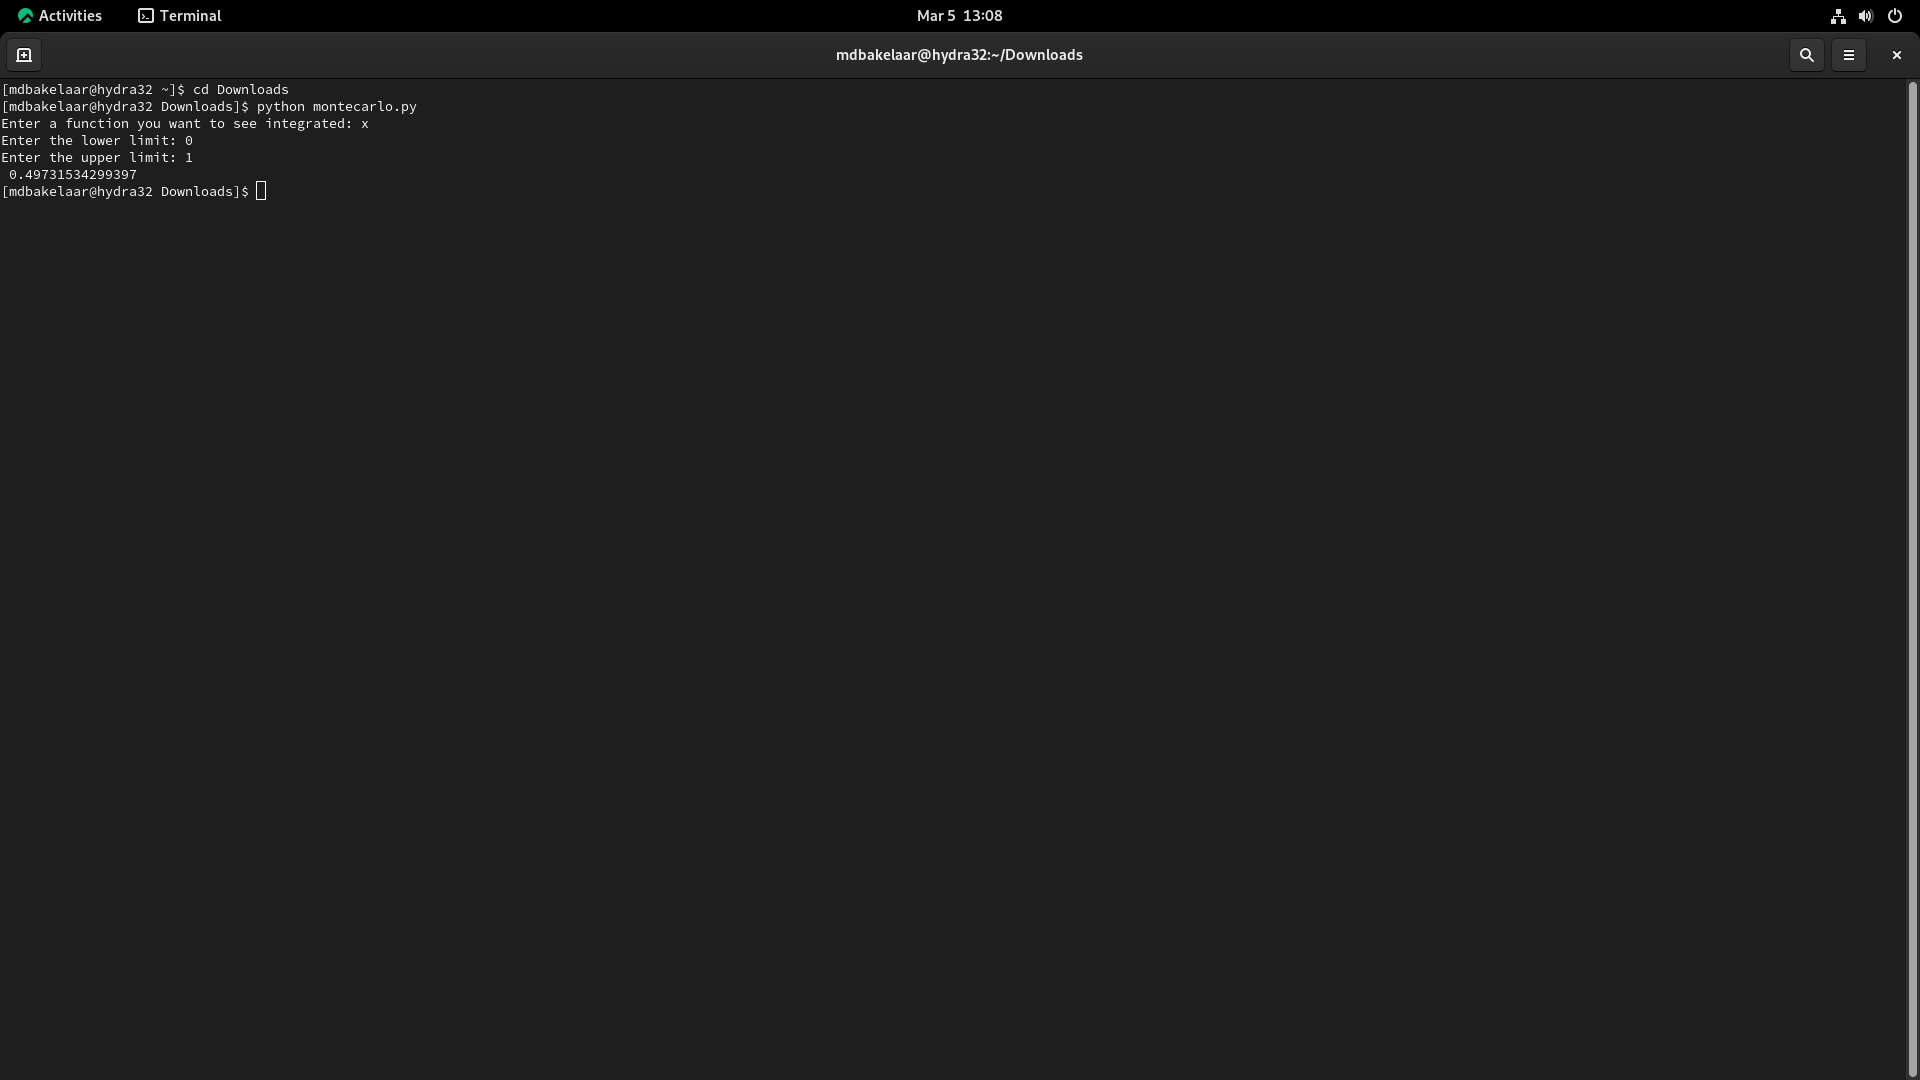

Question 4.7

$$ \Delta g = \sqrt{(\frac{4\pi^2}{T^2} \Delta L)^2 + (\frac{-8\pi^2L}{T^3} \Delta T)^2} $$

In [53]:
from math import *
import numpy as np

T = 2.01                                                                   #Our values for T and L and their errors
eT = 0.02
L = 1.00
eL = 0.01

G = (4*(pi**2)*L)/(T**2)                                                   #The formula for G
print(f"The calculated value for G using the given T and l: {G}")

errorG = sqrt((((4*(pi**2))/T**2)*eL)**2+(((-8*(pi**2)*L)/(T**3))*eT)**2)  #The formula to calculate the error in G
print(f"The error in G using the given error in T and L: {errorG}")

montcL = np.random.normal(1.00, 0.01, 100)                                 #Making normal distributions of our T and L 
arrayL = np.array(montcL)                                                  #Creating arrays of our T and L so we can randomly take numbers from them later to do the monte carlo errorprop.
montcT = np.random.normal(2.01, 0.02, 100)
arrayT = np.array(montcT)

indxL = np.random.randint(0, len(arrayL), 1)
indxT = np.random.randint(0, len(arrayT), 1)

listG = []
for i in range(0, 100, 1):                                                 #The monte carlo error propagation using randomly chosen points of our earlier created arrays of T and L
    indxL = np.random.randint(0, len(arrayL), 1)
    indxT = np.random.randint(0, len(arrayT), 1)
    G = (4*(pi**2)*arrayL[indxL])/(arrayT[indxT]**2)
    listG.append(G)

meanG = np.mean(listG)                                                     #The mean and standard deviation calculated using numpy and the values we got using monte carlo errorprop.
print(f"The calculated mean using monte carlo error propagation: {meanG}")
stdevG = np.std(listG)
print(f"The calculated standard deviation using monte carlo error propagation: {stdevG}")

The calculated value for G using the given T and l: 9.77164367326488
The error in G using the given error in T and L: 0.2176313753358241
The calculated mean using monte carlo error propagation: 9.770925190228475
The calculated standard deviation using monte carlo error propagation: 0.20817807644126557


Question 4.11

In [68]:
from math import *
import cmath                                                                    #Importing math for complex numbers

a = input("enter any integer for a: ")                                          #letting you input any integer
b = input("enter any integer for b: ")
c = input("enter any integer for c: ")

a = int(a)
b = int(b)
c = int(c)

D = b**2 - 4*a*c

if D>0:                                                                         #calculating for if D > 0
    x1 = (-b - sqrt(D))/(2*a)
    x2 = (-b + sqrt(D))/(2*a)
    e = f"your input values give x1 = (-b - sqrt(D))/(2*a): {x1} and x2 = (-b + sqrt(D))/(2*a): {x2}"
    print(e)
    f1 = a*x1**2 + b*x1 + c                                                    #filling the values and x1 and x2 back into the function to check if f=o
    f2 = a*x2**2 + b*x2 + c
    print(f"Filling the values and the calculated x1 back into f gives: {f1}")
    print(f"Filling the values and the calculated x2 back into f gives: {f2}")

elif D==0:                                                                     #calculating for if D = 0
    x = (-b + sqrt(D))/(2*a)
    print(f"Your input values give x = (-b + sqrt(D))/(2*a): {x}")
    f1 = a*x1**2 + b*x1 + c                                                    #filling the values and x1 and x2 back into the function to check if f=o
    print(f"Filling the values and the calculated x1 back into f gives: {f1}")

else:                                                                          #calculating the complex numbers if D < 0
    x1 = (-b + cmath.sqrt(D))/(2*a)
    x2 = (-b - cmath.sqrt(D))/(2*a)
    print(f"Your input values give the complex numbers: x1 = (-b + cmath.sqrt(D))/(2*a): {x1} and x2 = (-b - cmath.sqrt(D))/(2*a):{x2}")
    f1 = a*x1**2 + b*x1 + c                                                    #filling the values and x1 and x2 back into the function to check if f=o
    f2 = a*x2**2 + b*x2 + c
    print(f"Filling the values and the calculated x1 back into f gives: {f1}")
    print(f"Filling the values and the calculated x2 back into f gives: {f2}")

enter any integer for a:  1
enter any integer for b:  -13
enter any integer for c:  42


your input values give x1 = (-b - sqrt(D))/(2*a): 6.0 and x2 = (-b + sqrt(D))/(2*a): 7.0
Filling the values and the calculated x1 back into f gives: 0.0
Filling the values and the calculated x2 back into f gives: 0.0


question 4.12

(0.8660254037844387+0.49999999999999994j) 1.0


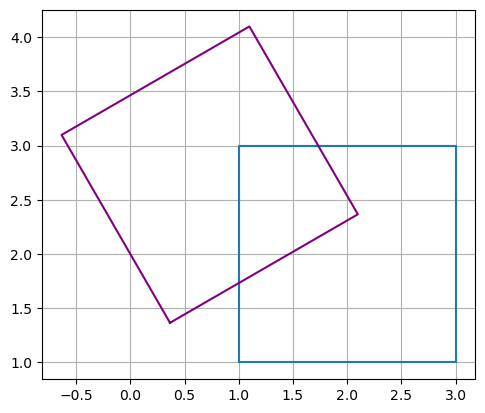

In [78]:
from matplotlib import pyplot as plt
import numpy as np
import math  

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

plt.plot(x,y)

theta = math.radians(30)
rotor = math.cos(theta) + 1j*math.sin(theta)
print(rotor, abs(rotor))  

XY = rotor * (x+y*1j)

plt.plot(XY.real, XY.imag, color='purple')
plt.gca().set_aspect(1)
plt.grid()
plt.show()

Question 4.14

In [96]:
import numpy as np

def funcfilter(func, seq):
    l = np.asarray(seq)
    lis = []
    if np.ndim(l) == 0:          #If there is only one index in the list ti will not do the following iteration and only append said singular scalar in the list
        l = np.array([l])
    for n in l:
        if n > 0:               #All numbers in the array above 0 get appended to the list
            lis.append(n)
    arraylis = np.array(lis)
    f = func(arraylis)           #The numbers get put into the function so the calculations can be done
    return f         

seq = np.array([-100, -10, 0, 10, 100])
func = np.log10
func1 = funcfilter(func, seq)
print(f"The result of test1; {func1}")                     #The result of a list with multiple scalars

g = funcfilter(np.log10, 100)
print(f"The result of test2: {g}")                         #The result of only a singular scalar

[1. 2.]
[2.]


Question 4.16

In [11]:
from astropy.cosmology import Planck18
from math import *
from scipy.integrate import quad


H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def Hz(z):
    y = H0 * sqrt(Om0 * (1+z)**3 + Ode0)
    return y

def tlz(z):
    intg = 1 / ((1+z)*Hz(z))
    return intg

a = 0.000001
z = float(input("Enter a number for z: "))

Area = quad(tlz, a, float(z))
print("Quad derived area under curve:", Area)


Enter a number for z:  2


Quad derived area under curve: (0.010765261486452906, 1.7097161074280172e-15)


In [13]:
from astropy.cosmology import Planck18
from math import *
from scipy.integrate import quad
import astropy.units as u

H0 = Planck18.H0.to(1/u.s).value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def Hz(z):
    y = H0 * sqrt(Om0 * (1+z)**3 + Ode0)
    return y

def tlz(z):
    intg = 1 / ((1+z)*Hz(z))
    return intg

a = 0.000001
z = float(input("Enter a number for z: "))

Area = quad(tlz, a, float(z))
seconds = quad(tlz, 0, z)[0]
Gyr = seconds / (60*60*24*365.25*1e9)
print("Quad derived area under curve:", Area)
print(Gyr)

Enter a number for z:  2


Quad derived area under curve: (3.321812602764018e+17, 52758.056044733516)
10.526203408163196


Question 4.21

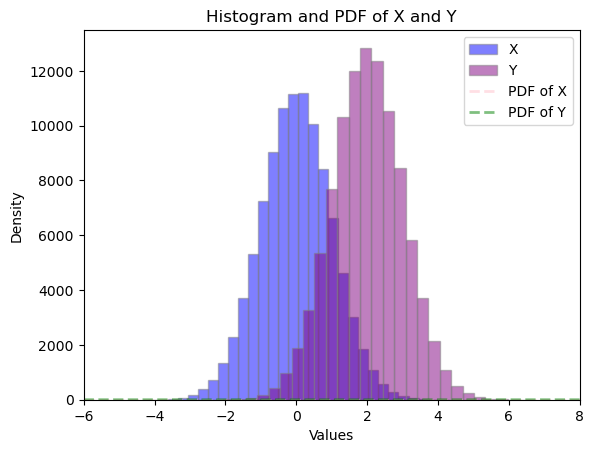

In [20]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

#Generating random normal distributions
X = np.random.normal(0, 1, 100000)                                                                               
Y = np.random.normal(2, 1, 100000)

#creating PDF
probdensX = gaussian_kde(X)
probdensY = gaussian_kde(Y)

val = np.linspace(-6, 8, 1000)

PDFX = probdensX(val)
PDFY = probdensY(val)

plt.hist(X, bins=30, alpha=0.5,edgecolor = 'grey', label='X', color= 'blue')
plt.hist(Y, bins=30, alpha=0.5, edgecolor = 'grey', label='Y', color = 'purple')

plt.plot(val, PDFX, alpha = 0.5, color='pink', linestyle= '--', linewidth = 2, label = "PDF of X")
plt.plot(val, PDFY, alpha = 0.5,  color = 'green', linestyle = '--', linewidth = 2, label = "PDF of Y")

plt.xlabel("Values")
plt.ylabel("Density")
plt.xlim(-6, 8)
plt.title("Histogram and PDF of X and Y")
plt.legend()
plt.show()

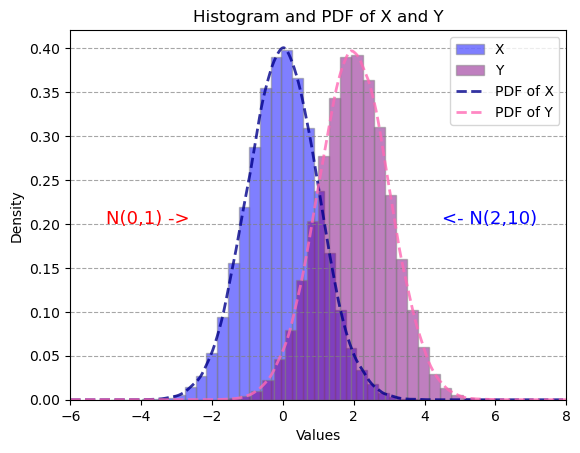

In [27]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

#Generating random normal distributions
X = np.random.normal(0, 1, 100000)                                                                               
Y = np.random.normal(2, 1, 100000)

#creating PDF
probdensX = gaussian_kde(X)
probdensY = gaussian_kde(Y)

val = np.linspace(-6, 8, 1000)

PDFX = probdensX(val)
PDFY = probdensY(val)

plt.hist(X, bins=30, density=True, alpha=0.5, edgecolor='grey', label='X', color='blue')
plt.hist(Y, bins=30, density=True, alpha=0.5, edgecolor='grey', label='Y', color='purple')

plt.plot(val, PDFX, alpha=0.8, color='darkblue', linestyle='--', linewidth=2, label="PDF of X")
plt.plot(val, PDFY, alpha=0.8, color='hotpink', linestyle='--', linewidth=2, label="PDF of Y")

plt.xlabel("Values")
plt.ylabel("Density")
plt.xlim(-6, 8)
plt.title("Histogram and PDF of X and Y")
plt.legend()
plt.grid(axis='y', linestyle='--', color='grey', alpha=0.7)
plt.text(-5, 0.2, "N(0,1) ->", size = 13, color = 'red')
plt.text(4.5, 0.2, "<- N(2,10)", size = 13, color = 'blue')
plt.show()



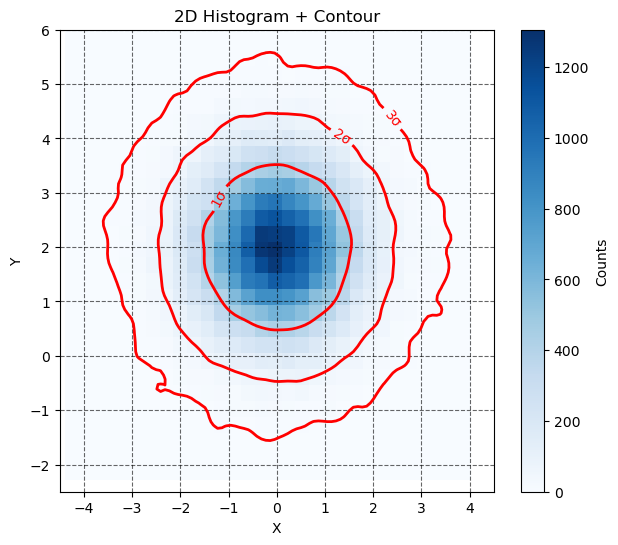

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

X = np.random.normal(0,1,100000)
Y = np.random.normal(2,1,100000)

plt.figure(figsize=(7,6))
plt.hist2d(X, Y, bins=30, cmap="Blues")
plt.colorbar(label="Counts")

xy = np.vstack([X,Y])
kde = gaussian_kde(xy)

x = np.linspace(-4.5,4.5,100)
y = np.linspace(-2.5,6,100)

Xgrid, Ygrid = np.meshgrid(x, y)
positions = np.vstack([Xgrid.ravel(), Ygrid.ravel()])

Z = np.reshape(kde(positions), Xgrid.shape)

levels = np.percentile(Z,[68,95,99.7])

z_flat = Z.flatten()
z_sort = np.sort(z_flat)[::-1]
cdf = np.cumsum(z_sort)
cdf /= cdf[-1]

levels = []
for p in [0.68, 0.95, 0.997]:
    idx = np.searchsorted(cdf, p)
    levels.append(z_sort[idx])


contours = plt.contour(Xgrid, Ygrid, Z, levels=sorted(levels), colors="red", linewidths = 2)

plt.clabel(contours, fmt={levels[0]: '1σ', levels[1]: '2σ', levels[2]: '3σ'}, colors = 'red') 

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Histogram + Contour")
plt.xlim(-4.5, 4.5)
plt.ylim(-2.5, 6)
plt.grid(True, linestyle='--', color='black', alpha = 0.6)
plt.show()